IM A LITTLE SHAOLIANG SHORT AND STOUT

In [13]:
import numpy as np

## Tutorial 5

In [1]:
import numpy as np
from numpy.linalg import inv, matrix_rank


def det_checker(X):
    m, d = X.shape
    if m == d:
        return "even"
    elif m > d:
        return "over"
    else:
        return "under"


def RC_checker(X, y):
    X_aug = np.append(X, y, axis=1)
    rankX = matrix_rank(X)
    rankX_ = matrix_rank(X_aug)
    d = X.shape[1]
    if rankX == rankX_:
        RC = 1 if rankX == d else 3
    else:
        RC = 2
    return RC, rankX, rankX_


def evenSolver(X, y):
    RC, _, _ = RC_checker(X, y)
    if RC == 1:
        return inv(X) @ y, "Unique solution."
    elif RC == 2:
        return None, "No solution."
    else:
        return None, "Infinitely many solutions."


def overSolver(X, y):
    RC, _, _ = RC_checker(X, y)
    if RC == 1:
        return inv(X.T @ X) @ X.T @ y, "Unique solution."
    elif RC == 3:
        return None, "Infinitely many solutions."
    else:
        return inv(X.T @ X) @ X.T @ y, "No exact sol, least square approx."


def underSolver(X, y):
    RC, _, _ = RC_checker(X, y)
    if RC == 2:
        return None, "No solution."
    else:
        return X.T @ inv(X @ X.T) @ y, "No exact sol, least norm approx."


def solveLE(X, y):
    det = det_checker(X)
    if det == "even":
        w, ans = evenSolver(X, y)
    elif det == "over":
        w, ans = overSolver(X, y)
    else:
        w, ans = underSolver(X, y)
    print(ans, "\nw =", w)
    return w


# --- Quick diagnostic ---
X = np.array([[1, 3], [1, 4], [1, 5], [1, 6], [1, 7]])
y = np.array([[5], [4], [3], [2], [1]])

print("System type:", det_checker(X))
RC, rX, rX_ = RC_checker(X, y)
print(f"rank(X)={rX}, rank(X~)={rX_}, case={RC}")
w = solveLE(X, y)

System type: over
rank(X)=2, rank(X~)=2, case=1
Unique solution. 
w = [[ 8.]
 [-1.]]


No exact sol, least square approx. 
w = [[9.3       ]
 [0.67272727]]
Predictions: [29.48181818 12.66363636]
No exact sol, least square approx. 
w = [[0.94987959]]


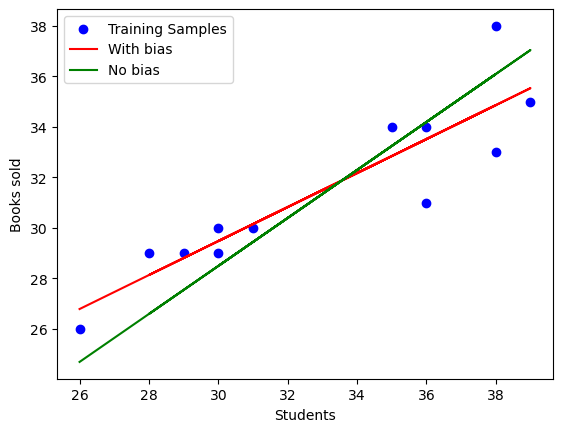

In [2]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[36], [28], [35], [39], [30], [30], [31], [38], [36], [38], [29], [26]])
y = np.array([[31], [29], [34], [35], [29], [30], [30], [38], [34], [33], [29], [26]])

# --- With bias ---
bias = np.ones((X.shape[0], 1))
X_b = np.hstack((bias, X))  # [1, x]
w = solveLE(X_b, y)  # w = [w0_bias, w1_slope]

# Predict for new inputs
X_test = np.array([[30], [5]])
X_test_b = np.hstack((np.ones((X_test.shape[0], 1)), X_test))
y_pred = X_test_b @ w
print("Predictions:", y_pred.ravel())

# --- Without bias ---
w_nb = solveLE(X, y)

# --- Plot both ---
plt.scatter(X, y, color="blue", label="Training Samples", marker="o")
plt.plot(X, X_b @ w, color="red", label="With bias")
plt.plot(X, X @ w_nb, color="green", label="No bias")
plt.xlabel("Students")
plt.ylabel("Books sold")
plt.legend()
plt.show()

In [3]:
# Multi-output regression (Tutorial 5 Q9) — multiple targets simultaneously
X = np.array([[3, -1, 0], [5, 1, 2], [9, -1, 3], [-6, 7, 2], [3, -2, 0]])
Y = np.array([[1, -1], [-1, 0], [1, 2], [0, 3], [1, -2]])  # two targets

bias = np.ones((X.shape[0], 1))
X_b = np.hstack((bias, X))
W = solveLE(X_b, Y)  # W shape (M+1, 2)

x_new = np.array([[8, 0, 2]])
x_new_b = np.hstack((np.ones((1, 1)), x_new))
y_new = x_new_b @ W  # two predictions
print("y_new =", y_new)

No exact sol, least square approx. 
w = [[ 1.14668974 -0.95997404]
 [-0.630463   -0.33427088]
 [-1.10601471 -0.24426655]
 [ 1.3595846   1.77953267]]
y_new = [[-1.17784509 -0.07507572]]


## Tutorial 6

In [4]:
from sklearn.preprocessing import PolynomialFeatures
from numpy.linalg import inv
import numpy as np


def polyTx(X, order):
    """Polynomial feature matrix with bias column. Shape: (N, order+1)."""
    return PolynomialFeatures(order).fit_transform(X)


def solvePR(P, y, ridge=False, lamb=0.01):
    """Solve polynomial regression. Auto primal (N>M) or dual (N<M)."""
    if ridge:
        if P.shape[0] > P.shape[1]:  # Primal
            w = inv(P.T @ P + lamb * np.eye(P.shape[1])) @ P.T @ y
        else:  # Dual
            w = P.T @ inv(P @ P.T + lamb * np.eye(P.shape[0])) @ y
    else:
        if P.shape[0] > P.shape[1]:  # Primal
            w = inv(P.T @ P) @ P.T @ y
        else:  # Dual
            w = P.T @ inv(P @ P.T) @ y
    return w


def solveLE_Ridge(X, y, lamb=0.01):
    """Linear regression with Ridge. X must already include bias column."""
    return solvePR(X, y, ridge=True, lamb=lamb)


# Quick test
X_test_poly = np.array([[-10], [-8], [-3], [-1], [2], [8]])
y_test_poly = np.array([[5], [5], [4], [3], [2], [2]])
P = polyTx(X_test_poly, 3)
print("P shape:", P.shape)  # (6, 4): [1, x, x^2, x^3]
w = solvePR(P, y_test_poly)
print("w:", w.ravel())

P shape: (6, 4)
w: [ 2.68935636 -0.37722517  0.01343815  0.00285772]


### PolynomialFeatures with a Single Input

`PolynomialFeatures` with a **single input** and `degree=3` gives exactly `[1, x, x², x³]` — no intermediates missing. It generates all powers from 0 up to the degree, so nothing in between is skipped.

It would be different with **multiple inputs**, e.g. degree 2 with x₁, x₂:

```
[1,  x₁,  x₂,  x₁²,  x₁x₂,  x₂²]  ← x₁x₂ is an "intermediate" interaction
```

But for a single-column case, the comment is fully accurate — no surprises.

---

#### Single Input Elaboration

With a single input `x` and `degree=3`, `PolynomialFeatures` just raises `x` to every integer power from 0 to 3:

```
degree 0 → x⁰ = 1       (bias)
degree 1 → x¹ = x
degree 2 → x²
degree 3 → x³
```

There are **no intermediates** because with only one variable, there's nothing to "interact" with — you can't form cross terms like x₁x₂. Every possible term is just a pure power of x, and all of them are included.

---

#### Example

```python
X = np.array([[-10], [-8], [-3], [-1], [2], [8]])  ### shape (6, 1)
P = polyTx(X, 3)  ### shape (6, 4)
```

Each row looks like:

```
x = -10  →  [1,  -10,  100,  -1000]
x =  -8  →  [1,   -8,   64,   -512]
x =   2  →  [1,    2,    4,      8]
```

Perfectly sequential, no gaps — the comment `[1, x, x^2, x^3]` is exactly right.

---

### Question 3(a): 3rd Order Polynomial with 3-Dimensional Input

For a **3rd order polynomial with 3-dimensional input** (x₁, x₂, x₃), you need ALL terms up to degree 3, including interactions.

#### The Expression

$$\hat{y} = w_0 + \underbrace{w_1x_1 + w_2x_2 + w_3x_3}_{\text{degree 1}} + \underbrace{w_4x_1^2 + w_5x_2^2 + w_6x_3^2 + w_7x_1x_2 + w_8x_1x_3 + w_9x_2x_3}_{\text{degree 2}} + \underbrace{w_{10}x_1^3 + w_{11}x_2^3 + w_{12}x_3^3 + w_{13}x_1^2x_2 + w_{14}x_1^2x_3 + w_{15}x_2^2x_1 + w_{16}x_2^2x_3 + w_{17}x_3^2x_1 + w_{18}x_3^2x_2 + w_{19}x_1x_2x_3}_{\text{degree 3}}$$

#### Term Count

| Degree | Terms | Examples |
|--------|-------|---------|
| 0 | 1 | 1 |
| 1 | 3 | x₁, x₂, x₃ |
| 2 | 6 | x₁², x₂², x₃², x₁x₂, x₁x₃, x₂x₃ |
| 3 | 10 | x₁³, x₂³, x₃³, x₁²x₂, x₁²x₃, x₂²x₁, x₂²x₃, x₃²x₁, x₃²x₂, x₁x₂x₃ |
| **Total** | **20** | |

#### In Code

```python
X  ### shape (N, 3) — three input features
P = PolynomialFeatures(degree=3).fit_transform(X)  ### shape (N, 20)
```

`PolynomialFeatures` handles all of this automatically — the 20 columns match exactly the terms above.

NOTICE: PolynomialFeatures column order may differ from handwritten version!
P:
 [[    1.   -10.   100. -1000.]
 [    1.    -8.    64.  -512.]
 [    1.    -3.     9.   -27.]
 [    1.    -1.     1.    -1.]
 [    1.     2.     4.     8.]
 [    1.     8.    64.   512.]]
Coefficients: [ 2.68935636 -0.37722517  0.01343815  0.00285772]
Prediction at x=9: [[2.46609771]]
No exact sol, least square approx. 
w = [[ 3.10550459]
 [-0.19724771]]
Linear pred at x=9: [[1.33027523]]


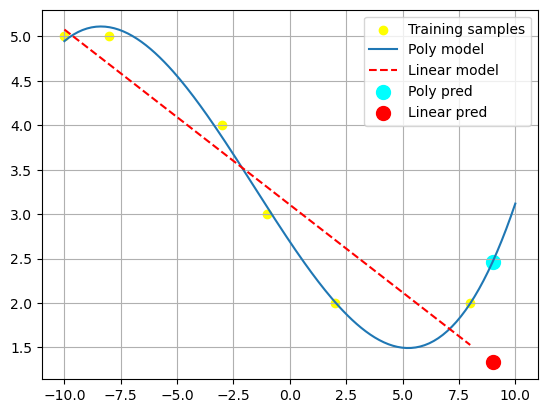

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Tutorial 6 Q2 dataset
X = np.array([[-10], [-8], [-3], [-1], [2], [8]])
y = np.array([[5], [5], [4], [3], [2], [2]])

order = 3
P = polyTx(X, order)  # shape (N, 4): [1, x, x^2, x^3]
print("NOTICE: PolynomialFeatures column order may differ from handwritten version!")
print("P:\n", P)

# Fit
w_poly = solvePR(P, y)
print("Coefficients:", w_poly.ravel())

# Predict on new point
x_test = np.array([[9]])
P_test = polyTx(x_test, order)  # same order
y_pred_poly = P_test @ w_poly
print("Prediction at x=9:", y_pred_poly)

# Compare with linear model
bias = np.ones((X.shape[0], 1))
X_ = np.hstack((bias, X))
w_lin = solveLE(X_, y)
x_test_ = np.hstack((np.ones((1, 1)), x_test))
y_pred_lin = x_test_ @ w_lin
print("Linear pred at x=9:", y_pred_lin)

# Plot
x_plot = np.linspace(-10, 10, 200).reshape(-1, 1)
P_plot = polyTx(x_plot, order)
plt.scatter(X, y, color="yellow", label="Training samples")
plt.plot(x_plot, P_plot @ w_poly, label="Poly model")
plt.plot(X, X_ @ w_lin, color="red", linestyle="--", label="Linear model")
plt.scatter(9, y_pred_poly, color="cyan", s=100, label="Poly pred")
plt.scatter(9, y_pred_lin, color="red", s=100, label="Linear pred")
plt.grid()
plt.legend()
plt.show()

In [6]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# --- Simple 3-class example (Tutorial 6 Q5) ---
# X already biased; Y has integer class labels 1/2/3
X = np.array([[1, -1], [1, 0], [1, 0.5], [1, 0.3], [1, 0.8]])
Y = np.array([[1], [1], [2], [3], [2]])

encoder = OneHotEncoder(sparse_output=False)
Y_onehot = encoder.fit_transform(Y)  # shape (N, n_classes)
print("One-hot Y:\n", Y_onehot)

W = solveLE(X, Y_onehot)  # weight matrix, shape (M, n_classes)

X_test = np.array([[1, -0.1], [1, 0.4]])
y_raw = X_test @ W
y_pred = encoder.inverse_transform(y_raw)
print("Predicted classes:", y_pred.ravel())

One-hot Y:
 [[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]
No exact sol, least square approx. 
w = [[ 0.47798742  0.33333333  0.18867925]
 [-0.64989518  0.55555556  0.09433962]]
Predicted classes: [1 2]


In [19]:
X = np.array([1, 1, 0, 1, 3, 3])
y = np.array([1, 0 , 1])
X_new = X.reshape(3,2)
y_new = y.reshape(-1, 1)
Tildae_X = np.hstack((X_new, y_new))
Tildae_X

array([[1, 1, 1],
       [0, 1, 0],
       [3, 3, 1]])

In [20]:
np.linalg.matrix_rank(X_new), np.linalg.matrix_rank(Tildae_X)

(np.int64(2), np.int64(3))

## Tutorial 7

In [14]:
import numpy as np

# =============================================================================
# SHAPE CONVENTION — applies to every feature-selection helper below
# =============================================================================
#   X : np.ndarray of shape (N, M)   -> N datapoints (rows), M features (cols)
#   y : np.ndarray of shape (N, 1)   -> target, one value per datapoint
#                                       (a 1-D (N,) vector is also accepted)
#
# WATCH OUT: the Tut 7 PDF tables list features as ROWS (3 features × 5 points).
# If you build a numpy array straight from the PDF, TRANSPOSE IT first:
#     X = data_from_pdf[:3].T   # (3, 5) -> (5, 3)
# Otherwise you'll compute "correlations across datapoints" instead of
# "correlation of each feature with y".
# =============================================================================

def _check_X_y(X, y, *, name):
    X = np.asarray(X)
    y = np.asarray(y).ravel()
    if X.ndim != 2:
        raise ValueError(f"{name}: X must be 2-D with shape (N, M); got shape {X.shape}")
    if X.shape[0] != y.size:
        raise ValueError(
            f"{name}: len(y)={y.size} must equal X.shape[0]={X.shape[0]}. "
            f"Did you forget to transpose? If the PDF listed features as rows, "
            f"use X = data[:M].T so rows=datapoints, cols=features."
        )
    return X, y


def pearson_corr_manual(a, b):
    """
    Pearson's r between two 1-D vectors, using the biased (1/N) estimator
    per the EE2211 Tut 7 definition.
    """
    a, b = np.asarray(a).ravel(), np.asarray(b).ravel()
    if a.size != b.size:
        raise ValueError(f"pearson_corr_manual: len(a)={a.size} != len(b)={b.size}")
    a_bar, b_bar = a.mean(), b.mean()
    cov = np.mean((a - a_bar) * (b - b_bar))
    sa  = np.sqrt(np.mean((a - a_bar) ** 2))
    sb  = np.sqrt(np.mean((b - b_bar) ** 2))
    return cov / (sa * sb)


def feature_pearson_scores(X, y):
    """|Pearson r| between each FEATURE COLUMN of X and target y. Shape (M,)."""
    X, y = _check_X_y(X, y, name='feature_pearson_scores')
    return np.array([abs(pearson_corr_manual(X[:, j], y)) for j in range(X.shape[1])])


def select_top_k_features(X, y, k):
    """
    Top-k feature selection by |Pearson r| with y.

    Returns
    -------
    X_selected : (N, k) array   columns of X indexed by top_idx
    top_idx    : (k,) int array column indices of X, sorted by |r| descending
    scores     : (M,) array     |r| for every column of X (unsorted)
    """
    X, y = _check_X_y(X, y, name='select_top_k_features')
    if not (1 <= k <= X.shape[1]):
        raise ValueError(f"select_top_k_features: k={k} out of range 1..{X.shape[1]}")
    scores  = feature_pearson_scores(X, y)
    top_idx = np.argsort(-scores)[:k]
    return X[:, top_idx], top_idx, scores


# Quick sanity check
a = np.array([1., 2., 3., 4., 5.])
b = np.array([2., 4., 6., 8., 9.])
print('pearson_corr_manual:', pearson_corr_manual(a, b))
print('np.corrcoef (same) :', np.corrcoef(a, b)[0, 1])


pearson_corr_manual: 0.9938837346736189
np.corrcoef (same) : 0.9938837346736188


### Q1

In [15]:
data = np.array(
    [
        [0.3510, 2.1812, 0.2415, -0.1096, 0.1544],  # Feature 1
        [1.1796, 2.1068, 1.7753, 1.2747, 2.0851],  # Feature 2
        [-0.9852, 1.3766, -1.3244, -0.6316, -0.8320],  # Feature 3
        [0.2758, 1.4392, -0.4611, 0.6154, 1.0006],  # Target y
    ]
)
X = data[:-1, :].T
y = data[-1, :].reshape(-1,)
# X.shape, y.shape
select_top_k_features(X, y, 2)

(array([[-0.9852,  0.351 ],
        [ 1.3766,  2.1812],
        [-1.3244,  0.2415],
        [-0.6316, -0.1096],
        [-0.832 ,  0.1544]]),
 array([2, 0]),
 array([0.59877228, 0.45369219, 0.80089165]))

### Q2

In [28]:
from sklearn.preprocessing import PolynomialFeatures
from numpy.linalg import inv
import numpy as np


def polyTx(X, order):
    """Polynomial feature matrix with bias column. Shape: (N, order+1)."""
    return PolynomialFeatures(order).fit_transform(X)


def solvePR(P, y, ridge=False, lamb=0.01):
    """Solve polynomial regression. Auto primal (N>M) or dual (N<M)."""
    if ridge:
        if P.shape[0] > P.shape[1]:  # Primal
            w = inv(P.T @ P + lamb * np.eye(P.shape[1])) @ P.T @ y
        else:  # Dual
            w = P.T @ inv(P @ P.T + lamb * np.eye(P.shape[0])) @ y
    else:
        if P.shape[0] > P.shape[1]:  # Primal
            w = inv(P.T @ P) @ P.T @ y
        else:  # Dual
            w = P.T @ inv(P @ P.T) @ y
    return w


def solveLE_Ridge(X, y, lamb=0.01):
    """Linear regression with Ridge. X must already include bias column."""
    return solvePR(X, y, ridge=True, lamb=lamb)


# Quick test
X_test_poly = np.array([[-10], [-8], [-3], [-1], [2], [8]])
y_test_poly = np.array([[5], [5], [4], [3], [2], [2]])
P = polyTx(X_test_poly, 3)
print("P shape:", P.shape)  # (6, 4): [1, x, x^2, x^3]
w = solvePR(P, y_test_poly)
print("w:", w.ravel())

P shape: (6, 4)
w: [ 2.68935636 -0.37722517  0.01343815  0.00285772]


In [29]:
from sklearn.metrics import mean_squared_error  # alternative to np.mean((...)**2)

# =============================================================================
# SHAPE CONVENTION for polyorder_sweep
# =============================================================================
#   X_train, X_test : (N_tr, d) and (N_te, d)   rows = datapoints
#       For 1-D input with a single scalar feature (Tut 7 Q2), d=1 and you
#       MUST pass a column vector, e.g. np.array([[-10],[-8],...]) not
#       np.array([-10, -8, ...]).  PolynomialFeatures requires 2-D input.
#
#   y_train, y_test : (N_tr, 1) and (N_te, 1)   column vectors
#       A 1-D (N,) array also works, but the weight vector returned will then
#       be 1-D as well. For consistency with the rest of the cheatsheet, we
#       recommend reshaping targets to (N, 1).
#
#   orders : iterable[int]   polynomial degrees to try (e.g. range(1, 7))
#   ridge  : bool            add L2 regularization
#   lamb   : float           ridge strength (only read if ridge=True)
# =============================================================================


def _check_poly_inputs(X_train, y_train, X_test, y_test):
    X_train, X_test = np.asarray(X_train), np.asarray(X_test)
    y_train, y_test = np.asarray(y_train), np.asarray(y_test)
    for name, A in [("X_train", X_train), ("X_test", X_test)]:
        if A.ndim != 2:
            raise ValueError(
                f"{name} must be 2-D with shape (N, d); got shape {A.shape}. "
                f"For scalar input, reshape with .reshape(-1, 1)."
            )
    if X_train.shape[1] != X_test.shape[1]:
        raise ValueError(
            f"X_train has {X_train.shape[1]} feature(s), X_test has {X_test.shape[1]} — must match."
        )
    if y_train.shape[0] != X_train.shape[0]:
        raise ValueError(
            f"len(y_train)={y_train.shape[0]} != X_train.shape[0]={X_train.shape[0]}"
        )
    if y_test.shape[0] != X_test.shape[0]:
        raise ValueError(
            f"len(y_test)={y_test.shape[0]} != X_test.shape[0]={X_test.shape[0]}"
        )
    return X_train, y_train, X_test, y_test


def polyorder_sweep(
    X_train, y_train, X_test, y_test, orders=range(1, 7), ridge=False, lamb=0.0
):
    """
    Fit polynomial regression at each order in `orders` and record train/test MSE.

    Parameters
    ----------
    X_train : (N_tr, d) array  rows = training datapoints (d=1 for Tut 7 Q2)
    y_train : (N_tr, 1) array  training targets (column vector preferred)
    X_test  : (N_te, d) array  rows = test datapoints
    y_test  : (N_te, 1) array  test targets
    orders  : iterable[int]    polynomial degrees, e.g. range(1, 7)
    ridge   : bool             if True, apply ridge (L2) regularization
    lamb    : float            ridge strength (ignored when ridge=False)

    Returns
    -------
    train_mse : (len(orders),) array
    test_mse  : (len(orders),) array
    weights   : list of weight vectors, one per order
                (shapes vary: (order+1, 1) for d=1, more for multi-feature X)

    Notes
    -----
    Uses `polyTx` (PolynomialFeatures) for features and `solvePR` (auto
    primal/dual) for weights — so it picks the right form automatically when
    the polynomial expansion makes the system over- or under-determined.
    """
    X_train, y_train, X_test, y_test = _check_poly_inputs(
        X_train, y_train, X_test, y_test
    )
    orders = list(orders)
    train_mse, test_mse, weights = [], [], []
    for o in orders:
        P_tr = polyTx(X_train, o)
        P_te = polyTx(X_test, o)
        w = solvePR(P_tr, y_train, ridge=ridge, lamb=lamb)
        train_mse.append(np.mean((P_tr @ w - y_train) ** 2))
        test_mse.append(np.mean((P_te @ w - y_test) ** 2))
        weights.append(w)
    return np.array(train_mse), np.array(test_mse), weights


def plot_mse_vs_order(orders, train_mse, test_mse, title="Train vs Test MSE"):
    """
    Quick-look chart of train / test MSE across polynomial orders.

    Parameters
    ----------
    orders    : iterable[int]  x-axis (polynomial degrees)
    train_mse : array-like     y-values for the Train MSE line
    test_mse  : array-like     y-values for the Test  MSE line
    title     : str            plot title
    """
    plt.figure()
    plt.plot(list(orders), train_mse, "o-", label="Train MSE")
    plt.plot(list(orders), test_mse, "s-", label="Test MSE")
    plt.xlabel("Polynomial order")
    plt.ylabel("MSE")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()


# Smoke test on the Tut 6 dataset: order 3 should recover the solvePR result exactly.
X_s = np.array([[-10], [-8], [-3], [-1], [2], [8]])
y_s = np.array([[5], [5], [4], [3], [2], [2]])
tr, te, ws = polyorder_sweep(X_s, y_s, X_s, y_s, orders=[1, 2, 3], ridge=False)
print("Smoke train MSE:", np.round(tr, 4))
print("Smoke test  MSE:", np.round(te, 4))

# Shape-check demo: would raise if uncommented (1-D X not allowed).
# bad_X = np.array([-10, -8, -3, -1, 2, 8])        # 1-D — must be (N, 1)
# polyorder_sweep(bad_X, y_s, bad_X, y_s)          # ValueError with a hint

Smoke train MSE: [0.1697 0.1284 0.0063]
Smoke test  MSE: [0.1697 0.1284 0.0063]


order   train MSE    test MSE
    1      2.3071      3.0006
    2      0.0084      0.0296
    3      0.0083      0.0301
    4      0.0017      0.0854
    5      0.0000      1.0548
    6      0.0000     10.7674

Best order (train): 5
Best order (test) : 2


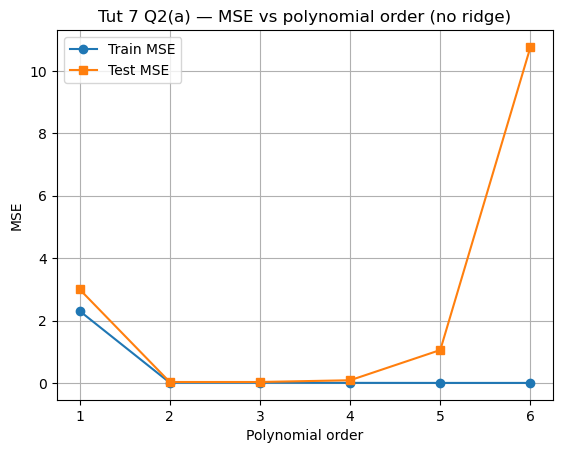

In [30]:
# --- Tutorial 7 Q2 datasets (verbatim from PDF) ---
# Training: 6 points (underlying = quadratic + noise)
X_train_tut7 = np.array([[-10], [-8], [-3], [-1], [2], [7]])
y_train_tut7 = np.array([[4.18], [2.42], [0.22], [0.12], [0.25], [3.09]])

# Test: 10 "clean" points. PDF also lists a trailing {x=-9}->{y=-6} outlier; include below if required.
X_test_tut7 = np.array([[-9], [-7], [-5], [-4], [-2], [1], [4], [5], [6], [9]])
y_test_tut7 = np.array(
    [[3.0], [1.81], [0.80], [0.25], [-0.19], [0.4], [1.24], [1.68], [2.32], [5.05]]
)

# --- Optional: include the trailing outlier from the PDF ({x=-9, y=-6}) ---
# X_test_tut7 = np.vstack([X_test_tut7, [[-9]]])
# y_test_tut7 = np.vstack([y_test_tut7, [[-6.0]]])

orders = range(1, 7)
train_mse, test_mse, _ = polyorder_sweep(
    X_train_tut7, y_train_tut7, X_test_tut7, y_test_tut7, orders=orders, ridge=False
)

print(f'{"order":>5}  {"train MSE":>10}  {"test MSE":>10}')
for o, tr, te in zip(orders, train_mse, test_mse):
    print(f"{o:>5}  {tr:>10.4f}  {te:>10.4f}")

print("\nBest order (train):", list(orders)[np.argmin(train_mse)])
print("Best order (test) :", list(orders)[np.argmin(test_mse)])

plot_mse_vs_order(
    orders,
    train_mse,
    test_mse,
    title="Tut 7 Q2(a) — MSE vs polynomial order (no ridge)",
)

# Expected narrative:
# - Train MSE monotonically decreases with order (more capacity -> can overfit 6 points).
# - Order 5 interpolates the training set exactly -> train MSE = 0.
# - Test MSE minimized near order 2 (matches the quadratic ground truth).
# - Higher orders explode on test -> classic overfitting signature.

order   train MSE    test MSE
    1      2.3586      3.2756
    2      0.0085      0.0302
    3      0.0084      0.0314
    4      0.0018      0.0939
    5      0.0007      0.4369
    6      0.0002      6.0202

Best order (train): 6
Best order (test) : 2


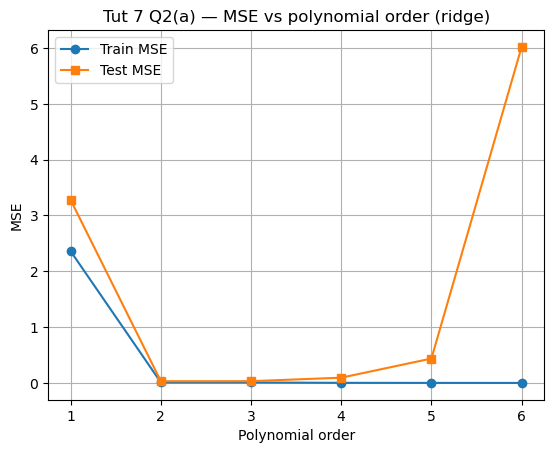

In [31]:
orders = range(1, 7)
train_mse, test_mse, _ = polyorder_sweep(
    X_train_tut7, y_train_tut7, X_test_tut7, y_test_tut7, orders=orders, ridge=True, lamb=1
)

print(f'{"order":>5}  {"train MSE":>10}  {"test MSE":>10}')
for o, tr, te in zip(orders, train_mse, test_mse):
    print(f"{o:>5}  {tr:>10.4f}  {te:>10.4f}")

print("\nBest order (train):", list(orders)[np.argmin(train_mse)])
print("Best order (test) :", list(orders)[np.argmin(test_mse)])

plot_mse_vs_order(
    orders,
    train_mse,
    test_mse,
    title="Tut 7 Q2(a) — MSE vs polynomial order (ridge)",
)

## Tutorial 8

### Q2

In [16]:
# --- 1D scalar gradient descent (from A3 — simpler than vectorised version) ---
def gd_1d(grad_fn, x0, lr, num_iters):
    """1D GD: returns trajectory array of length num_iters."""
    x = float(x0)
    traj = np.empty(num_iters)
    for i in range(num_iters):
        x = x - lr * grad_fn(x)
        traj[i] = x
    return traj


# --- 2D scalar gradient descent (from A3 Task C) ---
def gd_2d(grad_fn, u0, v0, lr, num_iters):
    """2D GD: grad_fn(u,v) -> (du, dv). Returns (u_traj, v_traj)."""
    u, v = float(u0), float(v0)
    ut, vt = np.empty(num_iters), np.empty(num_iters)
    for i in range(num_iters):
        gu, gv = grad_fn(u, v)
        u, v = u - lr * gu, v - lr * gv
        ut[i], vt[i] = u, v
    return ut, vt


# ── Quick demo: Tut 8 Q1 — f(x)=x^4, x0=2, lr=0.1, one step ──
df_x4 = lambda x: 4 * x**3
traj = gd_1d(df_x4, x0=2.0, lr=0.1, num_iters=1)
print(f"Q1: x after 1 iter = {traj[0]}")  # 2 - 0.1*4*8 = 2 - 3.2 = -1.2


# ── LR sensitivity analysis (A3 Task A pattern) ──
# f(x)=(x-3)^2+5, x0=10
f_A = lambda x: (x - 3) ** 2 + 5
df_A = lambda x: 2 * (x - 3)
lr_list = [0.001, 0.1, 0.5, 0.9, 1.0, 1.1]
num_iters = 100

trajs = {lr: gd_1d(df_A, 10.0, lr, num_iters) for lr in lr_list}
final_f = {lr: float(f_A(trajs[lr][-1])) for lr in lr_list}

diverging_lrs = sorted(lr for lr in lr_list if abs(trajs[lr][-1]) > 1e6)
converged_lrs = sorted(lr for lr in lr_list if final_f[lr] < 5.1)  # near min=5
print(f"Diverging LRs : {diverging_lrs}")
print(f"Converged LRs : {converged_lrs}")


# ── Multi-basin detection (A3 Task B pattern) ──
# f(x)=x^4-8x^2+x+10  — two local minima (left & right)
f_B = lambda x: x**4 - 8 * x**2 + x + 10
df_B = lambda x: 4 * x**3 - 16 * x + 1
inits = [-3.0, -1.0, 0.0, 1.0, 3.0]

final_x = {}
final_fB = {}
for x0 in inits:
    t = gd_1d(df_B, x0, lr=0.01, num_iters=5000)
    final_x[x0] = float(t[-1])
    final_fB[x0] = float(f_B(t[-1]))

left_basin = sorted(x0 for x0 in inits if final_x[x0] < 0)
right_basin = sorted(x0 for x0 in inits if final_x[x0] >= 0)
best_f = round(min(final_fB.values()), 2)
print(f"Left-basin inits : {left_basin}")
print(f"Right-basin inits: {right_basin}")
print(f"Best f found      : {best_f}")


# ── 2D basin counting (A3 Task C pattern) ──
# f(u,v) = sin(u)cos(v) + 0.1(u^2+v^2)
f_C = lambda u, v: np.sin(u) * np.cos(v) + 0.1 * (u**2 + v**2)
grad_C = lambda u, v: (
    np.cos(u) * np.cos(v) + 0.2 * u,
    -np.sin(u) * np.sin(v) + 0.2 * v,
)
pairs = [[0.1, 0.1], [2.0, 2.0], [-2.0, 1.0], [1.0, -2.0]]

final_f_C = {}
for p in pairs:
    ut, vt = gd_2d(grad_C, p[0], p[1], lr=0.05, num_iters=3000)
    final_f_C[str(p)] = float(f_C(ut[-1], vt[-1]))

rounded = {k: round(v, 1) for k, v in final_f_C.items()}
num_basins = len(set(rounded.values()))
print(f"Distinct basins found: {num_basins}  (rounded f values: {rounded})")

Q1: x after 1 iter = -1.2000000000000002
Diverging LRs : [1.1]
Converged LRs : [0.1, 0.5, 0.9]
Left-basin inits : [-3.0, -1.0, 0.0]
Right-basin inits: [1.0, 3.0]
Best f found      : -8.02
Distinct basins found: 2  (rounded f values: {'[0.1, 0.1]': -0.8, '[2.0, 2.0]': 0.0, '[-2.0, 1.0]': -0.8, '[1.0, -2.0]': 0.0})


In [17]:
# --- Reusable gradient-descent loop ---
# grad_fn(w) -> (cost_scalar, gradient_vector)
def gradient_descent(grad_fn, w0, lr, n_iters, record_every=1):
    """Vanilla GD. Returns final w and a cost history.

    grad_fn(w) must return (cost, gradient) with gradient.shape == w0.shape.
    """
    w = np.array(w0, dtype=float).copy()
    cost_hist = np.zeros(n_iters // record_every)
    for t in range(n_iters):
        cost, g = grad_fn(w)
        if t % record_every == 0:
            cost_hist[t // record_every] = cost
        w = w - lr * g
    return w, cost_hist


# --- Exponential model helper from Tut 8 Q2 ---
# f(x, w) = exp(-x^T w), square loss; gradient = -2 * (pred - y) * pred @ X
def exp_cost_gradient(X, w, y):
    """Forward + cost + gradient for exp(-x^T w) under square loss."""
    pred_y = np.exp(-X @ w)
    cost = np.sum((pred_y - y) ** 2)
    grad = -2 * (pred_y - y) * pred_y @ X
    return pred_y, cost, grad


# --- Smoke test: GD on f(x) = x^4 (Tut 8 Q1: x0=2, lr=0.1 -> x1 = -1.2) ---
def x4_grad_fn(w):
    return float(w[0] ** 4), 4 * w[0] ** 3 * np.ones_like(w)


w_final, hist = gradient_descent(x4_grad_fn, w0=np.array([2.0]), lr=0.1, n_iters=7)
print("Q1 check — first 7 iterates of x^4 with lr=0.1 (should oscillate/diverge):")
# reconstruct iterate path for visibility
x, path = 2.0, [2.0]
for _ in range(6):
    x = x - 0.1 * 4 * x**3
    path.append(round(x, 4))
print(path)

Q1 check — first 7 iterates of x^4 with lr=0.1 (should oscillate/diverge):
[2.0, -1.2, -0.5088, -0.4561, -0.4182, -0.3889, -0.3654]


In [18]:
# Full GD fit for Tut 8 Q2 — load, normalize, train, extrapolate.
def fit_exp_model(
    csv_path,
    lr=0.03,
    n_iters=200_000,
    year_col="year",
    value_col="total_expenditure_on_education",
):
    df = pd.read_csv(csv_path)
    y_raw = df[value_col].to_numpy().astype(float)
    years = df[year_col].to_numpy().astype(float)

    max_y, max_yr = y_raw.max(), years.max()
    y = y_raw / max_y
    X = np.ones((len(y), 2))
    X[:, 1] = years / max_yr

    def grad_fn(w):
        _, c, g = exp_cost_gradient(X, w, y)
        return c, g

    w, hist = gradient_descent(grad_fn, np.zeros(2), lr=lr, n_iters=n_iters)
    return dict(
        w=w, cost_hist=hist, years=years, y_raw=y_raw, max_y=max_y, max_yr=max_yr
    )


def predict_exp_model(fit, year_array):
    X = np.ones((len(year_array), 2))
    X[:, 1] = np.asarray(year_array) / fit["max_yr"]
    return np.exp(-X @ fit["w"]) * fit["max_y"]


# Usage sketch (uncomment when the CSV is available):
# fit = fit_exp_model('../data/Tutorial 2 supp government-expenditure-on-education.csv',
#                     lr=0.03, n_iters=200_000)
# ext_years = np.arange(1981, 2024)
# preds     = predict_exp_model(fit, ext_years)
# plt.scatter(fit['years'], fit['y_raw'], label='data')
# plt.plot(ext_years, preds, 'r-', label='fit'); plt.legend(); plt.show()

## Tutorial 9

### Q1

In [19]:
import matplotlib.pyplot as plt

In [20]:
# --- Classification node metrics ---
def gini(counts):
    c = np.asarray(counts, dtype=float)
    n = c.sum()
    return 0.0 if n == 0 else float(1 - np.sum((c / n) ** 2))


def entropy(counts, base=2):
    c = np.asarray(counts, dtype=float)
    n = c.sum()
    if n == 0:
        return 0.0
    p = c[c > 0] / n
    return float(-np.sum(p * (np.log(p) / np.log(base))))


def misclass(counts):
    c = np.asarray(counts, dtype=float)
    n = c.sum()
    return 0.0 if n == 0 else float(1 - c.max() / n)


def weighted_children(*c_list):
    tot = sum(sum(c) for c in c_list)
    return {
        k: sum(sum(c) * fn(c) for c in c_list) / tot
        for k, fn in [("gini", gini), ("entropy", entropy), ("misclass", misclass)]
    }


def split_gain(parent, *children):
    return {
        f"{k}_gain": (gini if k == "gini" else entropy if k == "entropy" else misclass)(
            parent
        )
        - weighted_children(*children)[k]
        for k in ("gini", "entropy", "misclass")
    }

In [21]:
import math
# For QA
# triangle square circle
counts = [5, 5, 8]
gini(counts)
children = [[4, 0, 6], [1, 5, 2]]
(10 / 18) * gini(children[0]) + (8 / 18) *gini(children[1]) - gini(counts), split_gain(counts, *children)

(-0.14537037037037037,
 {'gini_gain': 0.14537037037037037,
  'entropy_gain': 0.42997242260989577,
  'misclass_gain': 0.16666666666666669})

## Q2

In [22]:
data = np.array([[1, 2], [0.8, 3], [2, 2.5], [2.5, 1], [3, 2.3], [4, 2.8], [4.2, 1.5], [6, 2.6], [6.3, 3.5], [7, 4], [8, 
3.5], [8.2, 5], [9, 4.5]]).T
mask = data[0] < 5
first_half = data[:, mask]
second_half = data[:, ~mask]

def mse(y):
    y = np.asarray(y, dtype=float)
    return 0.0 if len(y) == 0 else float(np.mean((y - y.mean()) ** 2))
mse(first_half), mse(second_half)

(1.0177551020408162, 4.052222222222222)

In [23]:
def regression_split(x, y, threshold):
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    L, R = y[x <= threshold], y[x > threshold]
    return dict(
        threshold=float(threshold),
        root_mse=mse(y),
        left=dict(n=len(L), mean=float(L.mean()) if len(L) else np.nan, mse=mse(L)),
        right=dict(n=len(R), mean=float(R.mean()) if len(R) else np.nan, mse=mse(R)),
        weighted_mse=(len(L) * mse(L) + len(R) * mse(R)) / len(y),
    )

data = np.array(
    [
        [1, 2],
        [0.8, 3],
        [2, 2.5],
        [2.5, 1],
        [3, 2.3],
        [4, 2.8],
        [4.2, 1.5],
        [6, 2.6],
        [6.3, 3.5],
        [7, 4],
        [8, 3.5],
        [8.2, 5],
        [9, 4.5],
    ]
).T
x = data[0]
y = data[1]
regression_split(x, y, threshold=5.0)

{'threshold': 5.0,
 'root_mse': 1.2223668639053253,
 'left': {'n': 7, 'mean': 2.1571428571428575, 'mse': 0.43673469387755093},
 'right': {'n': 6, 'mean': 3.85, 'mse': 0.5958333333333333},
 'weighted_mse': 0.5101648351648351}

In [24]:
## mse at root
mse(y)

1.2223668639053253

### Q3

In [25]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
housing.data[:, 0].shape, housing.target.shape

((20640,), (20640,))

|--- MedInc <= 5.04
|   |--- MedInc <= 3.07
|   |   |--- value: [1.36]
|   |--- MedInc >  3.07
|   |   |--- value: [2.09]
|--- MedInc >  5.04
|   |--- MedInc <= 6.82
|   |   |--- value: [2.91]
|   |--- MedInc >  6.82
|   |   |--- value: [4.22]



[Text(0.5, 0.8333333333333334, 'x[0] <= 5.035\nsquared_error = 1.332\nsamples = 20640\nvalue = 2.069'),
 Text(0.25, 0.5, 'x[0] <= 3.074\nsquared_error = 0.837\nsamples = 16255\nvalue = 1.735'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'squared_error = 0.561\nsamples = 7860\nvalue = 1.357'),
 Text(0.375, 0.16666666666666666, 'squared_error = 0.837\nsamples = 8395\nvalue = 2.089'),
 Text(0.75, 0.5, 'x[0] <= 6.82\nsquared_error = 1.221\nsamples = 4385\nvalue = 3.306'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'squared_error = 0.891\nsamples = 3047\nvalue = 2.906'),
 Text(0.875, 0.16666666666666666, 'squared_error = 0.778\nsamples = 1338\nvalue = 4.216')]

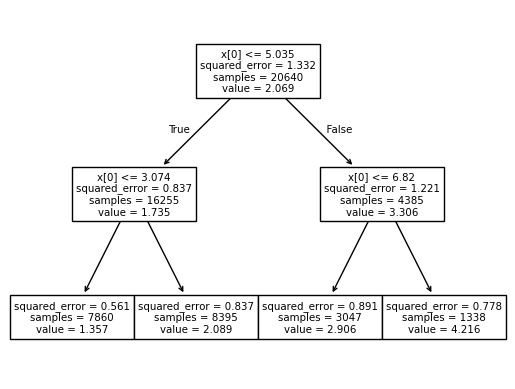

In [26]:
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
reg = DecisionTreeRegressor(criterion='squared_error', max_depth=2, random_state=0)
X_medinc = housing.data[:, 0].reshape(-1, 1) # Expects 2D
y = housing.target
reg.fit(X_medinc, y)
tree_rules = export_text(reg, feature_names=["MedInc"])
print(tree_rules)
plot_tree(reg)
# Read tree structure: thresholds, leaf means, per-node MSE
# t = reg.tree_
# for i in range(t.node_count):
#     is_leaf = t.children_left[i] == -1
#     print(i, 'leaf' if is_leaf else f'feat<={t.threshold[i]:.4f}',
#           'n=', t.n_node_samples[i], 'mean=', t.value[i,0,0], 'mse=', t.impurity[i])

In [27]:
def build_regression_tree(x, y, max_depth, min_samples=1, depth=0):
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    node = dict(
        depth=depth,
        n=len(y),
        mean=float(y.mean()) if len(y) else np.nan,
        mse=mse(y),
        leaf=True,
    )
    if depth >= max_depth or len(y) <= min_samples or np.unique(x).size < 2:
        return node
    b = find_best_split(x, y)
    if b is None or b["weighted_mse"] >= node["mse"] - 1e-12:
        return node
    m = x <= b["threshold"]
    node.update(
        leaf=False,
        threshold=b["threshold"],
        left=build_regression_tree(x[m], y[m], max_depth, min_samples, depth + 1),
        right=build_regression_tree(x[~m], y[~m], max_depth, min_samples, depth + 1),
    )
    return node
X_medinc = housing.data[:, 0]
y = housing.target
build_regression_tree(X_medinc, y, 2)

NameError: name 'find_best_split' is not defined

### Q4

In [ ]:
def fit_classification_tree(
    X,
    y,
    max_depth=4,
    criterion="entropy",
    test_size=0.2,
    random_state=0,
    feature_names=None,
    class_names=None,
    plot=True,
):
    from sklearn.model_selection import train_test_split
    from sklearn.tree import DecisionTreeClassifier, plot_tree
    from sklearn.metrics import accuracy_score

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    clf = DecisionTreeClassifier(
        max_depth=max_depth, criterion=criterion, random_state=random_state
    ).fit(X_tr, y_tr)
    train_acc = accuracy_score(y_tr, clf.predict(X_tr))
    test_acc = accuracy_score(y_te, clf.predict(X_te))
    print(f"train acc = {train_acc:.4f}  test acc = {test_acc:.4f}")
    if plot:
        fig, ax = plt.subplots(figsize=(14, 8))
        plot_tree(
            clf,
            feature_names=feature_names,
            class_names=class_names,
            filled=True,
            rounded=True,
            ax=ax,
        )
        plt.show()
    return dict(
        clf=clf,
        train_acc=train_acc,
        test_acc=test_acc,
        X_train=X_tr,
        X_test=X_te,
        y_train=y_tr,
        y_test=y_te,
    )

train acc = 0.9917  test acc = 1.0000


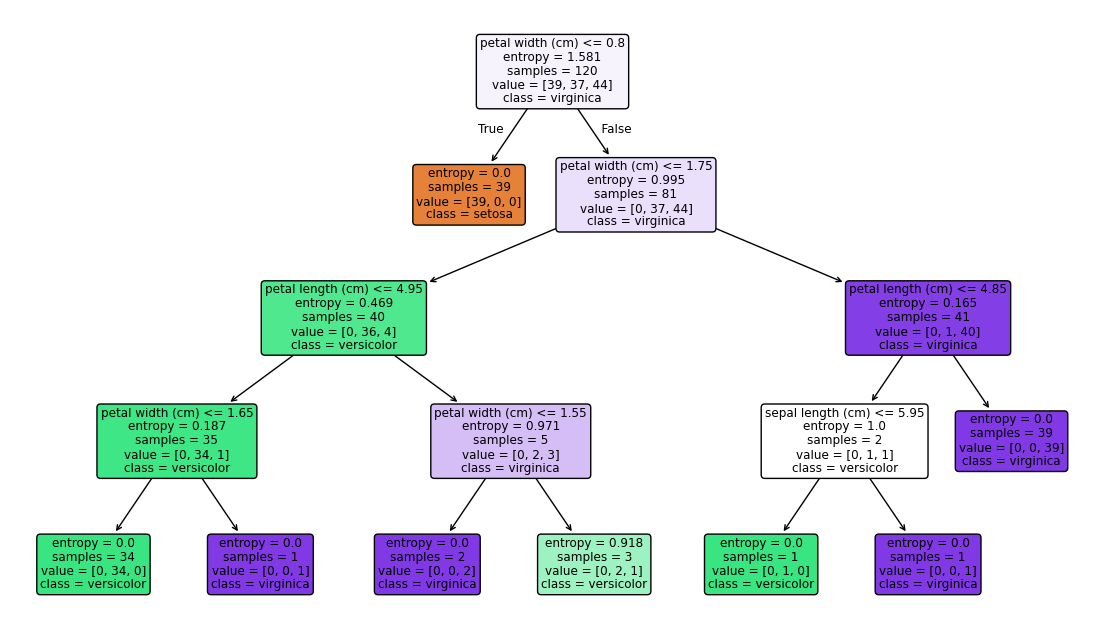

In [ ]:
# Classification tree (entropy, depth 4) — full 80/20 + plot in one helper
from sklearn.datasets import load_iris

iris = load_iris()
out = fit_classification_tree(
    iris.data,
    iris.target,
    max_depth=4,
    criterion="entropy",
    feature_names=iris.feature_names,
    class_names=list(iris.target_names),
)

## Tutorial 10

In [ ]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from numpy.linalg import inv


# ── make_folds ──────────────────────────────────────────────────────────────
def make_folds(n, k=5):
    """k-fold split over n samples (no shuffle; call on pre-shuffled data)."""
    fold_size = n // k
    folds = []
    for f in range(k):
        val_start = f * fold_size
        val_end = (f + 1) * fold_size if f < k - 1 else n
        val_idx = np.arange(val_start, val_end)
        train_idx = np.concatenate([np.arange(0, val_start), np.arange(val_end, n)])
        folds.append((train_idx, val_idx))
    return folds


# ── error_rate (OHE multi-class) ─────────────────────────────────────────────
def error_rate(P, W, Y_ohe):
    """Misclassification rate: argmax(PW) vs argmax(Y_ohe)."""
    pred = np.argmax(P @ W, axis=1)
    true = np.argmax(Y_ohe, axis=1)
    return np.mean(pred != true)


# ── kfold_poly_sweep ─────────────────────────────────────────────────────────
def kfold_poly_sweep(X, Y_ohe, orders, folds, lam=0.0):
    """
    For each polynomial order, compute average train/val error across k folds.
    Returns (tr_errs, va_errs) — same length as orders.
    Handles singular matrices with np.nan for that fold.
    """
    tr_errs, va_errs = [], []
    for order in orders:
        fold_tr, fold_va = [], []
        poly = PolynomialFeatures(degree=order, include_bias=True)
        for tr_idx, va_idx in folds:
            P_tr = poly.fit_transform(X[tr_idx])
            P_va = poly.transform(X[va_idx])
            try:
                PtP = P_tr.T @ P_tr
                W = inv(PtP + lam * np.eye(PtP.shape[0])) @ P_tr.T @ Y_ohe[tr_idx]
                fold_tr.append(error_rate(P_tr, W, Y_ohe[tr_idx]))
                fold_va.append(error_rate(P_va, W, Y_ohe[va_idx]))
            except np.linalg.LinAlgError:
                fold_tr.append(np.nan)
                fold_va.append(np.nan)
        tr_errs.append(np.nanmean(fold_tr))
        va_errs.append(np.nanmean(fold_va))
    return tr_errs, va_errs

Best order (no reg): 2   Best order (ridge): 2


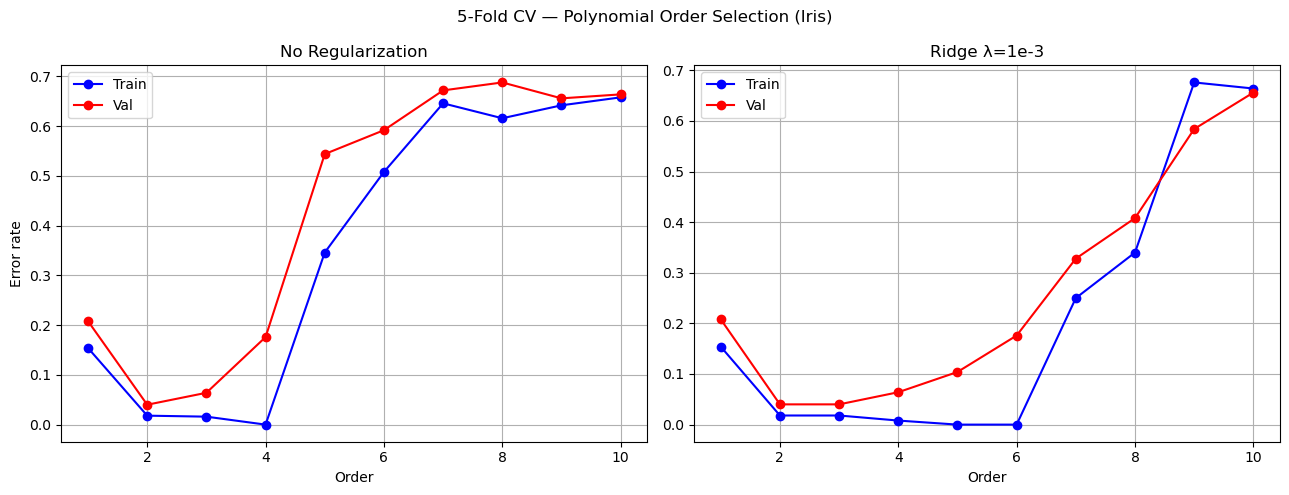

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import OneHotEncoder

iris = load_iris()
X_all, y_all = iris.data, iris.target
ohe = OneHotEncoder(sparse_output=False)
Y_all = ohe.fit_transform(y_all.reshape(-1, 1))  # (150, 3)

np.random.seed(42)
perm = np.random.permutation(150)
X_test, Y_test = X_all[perm[:25]], Y_all[perm[:25]]
X_cv, Y_cv = X_all[perm[25:]], Y_all[perm[25:]]

folds_iris = make_folds(len(X_cv), k=5)  # saved for future reuse

orders = list(range(1, 11))

# No regularization sweep
tr_no, va_no = kfold_poly_sweep(X_cv, Y_cv, orders, folds_iris, lam=0.0)
# With ridge sweep (handles singular matrix at high orders)
tr_r, va_r = kfold_poly_sweep(X_cv, Y_cv, orders, folds_iris, lam=1e-3)

best_no = orders[np.nanargmin(va_no)]
best_r = orders[np.nanargmin(va_r)]
print(f"Best order (no reg): {best_no}   Best order (ridge): {best_r}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(orders, tr_no, "b-o", label="Train")
ax1.plot(orders, va_no, "r-o", label="Val")
ax1.set_title("No Regularization")
ax1.set_xlabel("Order")
ax1.set_ylabel("Error rate")
ax1.legend()
ax1.grid(True)
ax2.plot(orders, tr_r, "b-o", label="Train")
ax2.plot(orders, va_r, "r-o", label="Val")
ax2.set_title("Ridge λ=1e-3")
ax2.set_xlabel("Order")
ax2.legend()
ax2.grid(True)
plt.suptitle("5-Fold CV — Polynomial Order Selection (Iris)")
plt.tight_layout()
plt.show()

## Tutorial 11

In [ ]:
x1 = np.array([1, 1]).reshape(-1)
x2 = np.array([0, 1]).reshape(-1)
x3 = np.array([1, 1]).reshape(-1)
x4 = np.array([1, 0]).reshape(-1)
x5 = np.array([3, 0]).reshape(-1)
x6 = np.array([3, 1]).reshape(-1)
x7 = np.array([4, 0]).reshape(-1)
x8 = np.array([4, 1]).reshape(-1)

In [ ]:
from sklearn.cluster import KMeans
import numpy as np

x = np.array([[0, 0], [0, 1], [1, 1], [1, 0], [3, 0], [3, 1], [4, 0], [4, 1]])
init_centroids = np.array([[0, 0], [3, 0]])
kmeans = KMeans(n_clusters=2, init=init_centroids, random_state=0, n_init=1)
kmeans.fit(x)
print("prediction: \n", kmeans.labels_)
print("centers: \n", kmeans.cluster_centers_)

prediction: 
 [0 0 0 0 1 1 1 1]
centers: 
 [[0.5 0.5]
 [3.5 0.5]]


c:\Users\shaol\anaconda3\envs\ml_workspace\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## Tutorial 12

In [ ]:
import numpy as np

def relu(x):     return np.maximum(0, x)
def sigmoid(x):  return 1.0 / (1.0 + np.exp(-x.astype(float)))
def softmax(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True))   # numerically stable
    return e / e.sum(axis=-1, keepdims=True)

# Quick sanity checks
print('relu(-1, 0, 2)  :', relu(np.array([-1, 0, 2])))
print('sigmoid(-2,0,2) :', np.round(sigmoid(np.array([-2, 0, 2])), 4))
print('softmax([1,2,3]):', np.round(softmax(np.array([1., 2., 3.])), 4))


relu(-1, 0, 2)  : [0 0 2]
sigmoid(-2,0,2) : [0.1192 0.5    0.8808]
softmax([1,2,3]): [0.09   0.2447 0.6652]


### Q3

In [ ]:
X = np.array([[1, 1, 3.0], [1, 2, 2.5]])
W1 = np.array([[-1, 0, 1], [0, -1, 0], [1, 0, 1]])
W2 = W1.copy()
relu(relu(X @ W1) @ W2)

array([[2., 0., 6.],
       [2., 0., 5.]])

### Q4

In [ ]:
X = np.array([[1, 2, 1], [1, 5, 1]])
W1 = np.array([[-1, 0, 1], [0, -1, 0], [1, 0, -1]])
W2 = np.array([[-1, 0, 1], [0, -1, 0], [1, 0, 1], [1, -1, 1]])
W3 = W2.copy()
X.shape, W1.shape, W2.shape, W3.shape

((2, 3), (3, 3), (4, 3), (4, 3))

In [ ]:
XW1 = sigmoid(X @ W1)
XW1

array([[0.5       , 0.11920292, 0.5       ],
       [0.5       , 0.00669285, 0.5       ]])

In [ ]:
N, M = XW1.shape
bias = np.ones((N, 1))
XW1_b = np.hstack((bias, XW1))
# sigmoid(sigmoid(XW1_b) @ W2)
last = sigmoid(XW1_b @ W2) 

In [ ]:
N, M = last.shape
bias = np.ones((N, 1))
help_b = np.hstack((bias, last))
sigmoid(help_b@W3)

array([[0.52588349, 0.22432811, 0.89125517],
       [0.52186405, 0.23188723, 0.88968347]])